In [1]:
import pandas as pd

df = pd.read_csv("diabetic_data.csv")

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())



c:\Users\Hifaz Khan\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Hifaz Khan\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Dataset shape: (101766, 50)

First 5 rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  .

In [2]:
print("\nColumns:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df["readmitted"].value_counts(dropna=False))


Columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Target distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


#### So our clinical question is specifically:At the time of hospital discharge, can we predict whether this patient will be readmitted within 30 days?

In [3]:
import numpy as np

# Keep an untouched copy of the raw dataset
df_raw = df.copy()

# --------------------------------------------------
# 1. Create binary 30-day readmission target
# --------------------------------------------------
df["target_30d"] = (df["readmitted"] == "<30").astype(int)

print("Binary target distribution:")
print(df["target_30d"].value_counts())

print("\nBinary target percentage:")
print(df["target_30d"].value_counts(normalize=True) * 100)


# --------------------------------------------------
# 2. Check encounter and patient IDs
# --------------------------------------------------
print("\nDuplicate encounter IDs:")
print(df["encounter_id"].duplicated().sum())

print("\nUnique patients:")
print(df["patient_nbr"].nunique())

patient_counts = df.groupby("patient_nbr").size()#In Pandas, .size() counts the total number of elements in an object, including missing or NaN values.

print("\nPatients with more than one encounter:")
print((patient_counts > 1).sum())

print("\nMaximum encounters for one patient:")
print(patient_counts.max())


# --------------------------------------------------
# 3. Check '?' missing-value markers
# --------------------------------------------------
question_missing = (df == "?").sum()
question_missing = question_missing[question_missing > 0].sort_values(ascending=False)

print("\nColumns containing '?':")
print(question_missing)

Binary target distribution:
target_30d
0    90409
1    11357
Name: count, dtype: int64

Binary target percentage:
target_30d
0    88.840084
1    11.159916
Name: proportion, dtype: float64

Duplicate encounter IDs:
0

Unique patients:
71518



Patients with more than one encounter:
16773

Maximum encounters for one patient:
40

Columns containing '?':
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


#### column names containing '?' and the '?' within each column was printed 

In [4]:
#Missing-data setup + clinical discharge check
#we don’t drop every row containing missing data. In healthcare datasets, missingness can itself reflect how care was delivered, so we first measure it and decide feature-by-feature.
import numpy as np
import pandas as pd

# Replace dataset-specific missing marker ie "?" with proper NaN
df = df.replace("?", np.nan)

# Calculate missing values
missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": (df.isna().mean() * 100).round(2)
})

missing = missing[missing["Missing_Count"] > 0]
missing = missing.sort_values("Missing_Percent", ascending=False)

print(missing)

                   Missing_Count  Missing_Percent
weight                     98569            96.86
max_glu_serum              96420            94.75
A1Cresult                  84748            83.28
medical_specialty          49949            49.08
payer_code                 40256            39.56
race                        2273             2.23
diag_3                      1423             1.40
diag_2                       358             0.35
diag_1                        21             0.02


____

A1Cresult and max_glu_serum look ~83% and ~95% “missing,” but in this dataset that often means the test was not performed, not that the information was accidentally lost. That distinction matters clinically. So we’ll preserve “not measured” as information rather than throwing those columns away. The dataset is explicitly about 30-day readmission after discharge, so excluding patients who died or went to hospice is also defensible because they are generally not meaningfully at risk for the same readmission outcome.
____

In [5]:
#load id mapping file to get to know what a discharge code could mean like home, another facility, hospice, or death. We need to know what each code means before deciding whether that encounter is clinically eligible for a 30-day readmission prediction
mapping = pd.read_csv("IDS_mapping.csv")

print(mapping.head(30))
print("\nShape:", mapping.shape)
print("\nColumns:")
print(mapping.columns.tolist())

           admission_type_id  \
0                          1   
1                          2   
2                          3   
3                          4   
4                          5   
5                          6   
6                          7   
7                          8   
8                        NaN   
9   discharge_disposition_id   
10                         1   
11                         2   
12                         3   
13                         4   
14                         5   
15                         6   
16                         7   
17                         8   
18                         9   
19                        10   
20                        11   
21                        12   
22                        13   
23                        14   
24                        15   
25                        16   
26                        17   
27                        18   
28                        19   
29                        20   

       

In [6]:
#Check which discharge codes actually occur
print(df["discharge_disposition_id"].value_counts().sort_index())

discharge_disposition_id
1     60234
2      2128
3     13954
4       815
5      1184
6     12902
7       623
8       108
9        21
10        6
11     1642
12        3
13      399
14      372
15       63
16       11
17       14
18     3691
19        8
20        2
22     1993
23      412
24       48
25      989
27        5
28      139
Name: count, dtype: int64


In [7]:
#Make the clinical cleaning decisions
#We exclude those specific patients—specifically those who died (expired) or were transferred to hospice care—because they are clinically ineligible for a standard 30-day hospital readmission.
exclude_discharge = [11, 13, 14, 19, 20, 21]

print("Rows before exclusion:", len(df))

df = df[~df["discharge_disposition_id"].isin(exclude_discharge)].copy()#~ means NOT 

print("Rows after exclusion:", len(df))
print("Rows removed:", len(df_raw) - len(df))

Rows before exclusion: 101766


Rows after exclusion: 99343
Rows removed: 2423


_____

Excluded clinically ineligible discharge outcomes  

From mapping:  

11 = Expired  
13 = Hospice / home  
14 = Hospice / medical facility  
19, 20 = expired-related categories  
21 is another death-related disposition in this coding system, though your data currently appears to contain zero rows with it.  

_____

In [8]:
#Drop weight
df = df.drop(columns=["weight"])

print("weight removed:", "weight" not in df.columns)

weight removed: True


In [9]:
#Preserve “test not performed”
df["max_glu_serum"] = df["max_glu_serum"].fillna("Not_measured")
df["A1Cresult"] = df["A1Cresult"].fillna("Not_measured")

print(df["max_glu_serum"].value_counts(dropna=False))
print()
print(df["A1Cresult"].value_counts(dropna=False))

max_glu_serum
Not_measured    94191
Norm             2545
>200             1419
>300             1188
Name: count, dtype: int64

A1Cresult
Not_measured    82509
>8               8137
Norm             4922
>7               3775
Name: count, dtype: int64


____

Informative missingness: the fact that a value is missing may itself contain useful information related to patient care or outcome.
____

In [ ]:
# -------------------------------------------
# 1. Drop payer_code
# -------------------------------------------
df = df.drop(columns=["payer_code"])#payment related info not that essential 


# -------------------------------------------
# 2. Fill remaining categorical missing values
# -------------------------------------------
fill_unknown = [# because info might be useful espescially race on which we can perform fairness analysis
    "medical_specialty",
    "race",
    "diag_1",
    "diag_2",
    "diag_3"
]

for col in fill_unknown:
    df[col] = df[col].fillna("Unknown")


# -------------------------------------------
# 3. Check remaining missing values
# -------------------------------------------
remaining_missing = df.isna().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining missing values:")
print(remaining_missing)


# -------------------------------------------
# 4. Check number of unique values                  #for checking variance 
# -------------------------------------------
unique_counts = df.nunique().sort_values()

print("\nColumns with 5 or fewer unique values:")
print(unique_counts[unique_counts <= 5])


# -------------------------------------------
# 5. Check gender values
# -------------------------------------------
print("\nGender distribution:")
print(df["gender"].value_counts(dropna=False))


Remaining missing values:
Series([], dtype: int64)



Columns with 5 or fewer unique values:
citoglipton                 1
examide                     1
target_30d                  2
diabetesMed                 2
change                      2
acetohexamide               2
metformin-pioglitazone      2
metformin-rosiglitazone     2
glimepiride-pioglitazone    2
glipizide-metformin         2
tolbutamide                 2
troglitazone                2
tolazamide                  3
gender                      3
readmitted                  3
insulin                     4
miglitol                    4
acarbose                    4
rosiglitazone               4
pioglitazone                4
glyburide-metformin         4
glyburide                   4
glipizide                   4
glimepiride                 4
chlorpropamide              4
nateglinide                 4
metformin                   4
A1Cresult                   4
max_glu_serum               4
repaglinide                 4
dtype: int64

Gender distribution:
gender
Female            

-----

here we should remove columns with zero variance cz they r not useful

-----

In [11]:
# -------------------------------------------
# 6. Recheck target after clinical exclusions
# -------------------------------------------
print("\nTarget distribution after exclusions:")
print(df["target_30d"].value_counts())

print("\nTarget percentage:")
print((df["target_30d"].value_counts(normalize=True) * 100).round(2))


Target distribution after exclusions:
target_30d
0    88029
1    11314
Name: count, dtype: int64

Target percentage:
target_30d
0    88.61
1    11.39
Name: proportion, dtype: float64


In [12]:
#drop unuseful features
# Save patient ID separately for grouped splitting/CV
groups = df["patient_nbr"].copy()

# Drop columns that must not become predictors
drop_cols = [
    "encounter_id",
    "patient_nbr",
    "readmitted",
    "examide",
    "citoglipton"
]

df = df.drop(columns=drop_cols)

# Clean tiny invalid gender category
df["gender"] = df["gender"].replace("Unknown/Invalid", "Unknown")

print("Current shape:", df.shape)
print("\nGender:")
print(df["gender"].value_counts())

Current shape: (99343, 44)

Gender:
gender
Female     53454
Male       45886
Unknown        3
Name: count, dtype: int64


#### clinical feature engineering:Use domain knowledge to convert very granular medical codes into broader, interpretable disease categories.

In [ ]:
#define groups to use them in place of diagnosis codes
def group_diagnosis(code):
    code = str(code)

    # Missing diagnosis
    if code == "Unknown":
        return "Unknown"

    # ICD-9 V and E codes
    if code.startswith("V") or code.startswith("E"):
        return "Other"

    try:
        code = float(code)
    except ValueError:
        return "Other"

    # Diabetes
    if 250 <= code < 251:
        return "Diabetes"

    # Circulatory
    elif (390 <= code < 460) or code == 785:
        return "Circulatory"

    # Respiratory
    elif (460 <= code < 520) or code == 786:
        return "Respiratory"

    # Digestive
    elif (520 <= code < 580) or code == 787:
        return "Digestive"

    # Genitourinary
    elif (580 <= code < 630) or code == 788:
        return "Genitourinary"

    # Neoplasms
    elif 140 <= code < 240:
        return "Neoplasms"

    # Musculoskeletal
    elif 710 <= code < 740:
        return "Musculoskeletal"

    # Injury / poisoning
    elif 800 <= code < 1000:
        return "Injury"

    else:
        return "Other"

In [ ]:
#Now apply it to all three diagnoses
for col in ["diag_1", "diag_2", "diag_3"]:
    df[col + "_group"] = df[col].apply(group_diagnosis)

# Examine the new groups
for col in ["diag_1_group", "diag_2_group", "diag_3_group"]:
    print(f"\n{col}:")
    print(df[col].value_counts())


diag_1_group:
diag_1_group
Circulatory        29681
Other              17793
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6853
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Unknown               20
Name: count, dtype: int64

diag_2_group:
diag_2_group
Circulatory        31158
Other              26027
Diabetes           12705
Respiratory        10390
Genitourinary       8147
Digestive           4088
Injury              2385
Neoplasms           2326
Musculoskeletal     1761
Unknown              356
Name: count, dtype: int64

diag_3_group:
diag_3_group
Circulatory        29600
Other              28589
Diabetes           16979
Respiratory         7005
Genitourinary       6436
Digestive           3857
Injury              1898
Musculoskeletal     1898
Neoplasms           1662
Unknown             1419
Name: count, dtype: int64


In [15]:
#remove the original raw ICD-code columns
df = df.drop(columns=["diag_1", "diag_2", "diag_3"])

print("\nFinal shape after diagnosis grouping:", df.shape)


Final shape after diagnosis grouping: (99343, 44)


____

Target leakage:Giving the model information derived from the outcome.  
Patient leakage:Records from the same patient appearing in both training and testing.  
____

In [16]:
#Leakage-safe train/test split
#Separate X and y
X = df.drop(columns=["target_30d"])
y = df["target_30d"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumerical columns:", X.select_dtypes(include=["int64", "float64"]).shape[1])
print("Categorical columns:", X.select_dtypes(include=["object"]).shape[1])

X shape: (99343, 43)
y shape: (99343,)

Numerical columns: 11
Categorical columns: 32


C:\Users\Hifaz Khan\AppData\Local\Temp\ipykernel_2236\1149053420.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical columns:", X.select_dtypes(include=["object"]).shape[1])


In [ ]:
#Patient-level train/test split
from sklearn.model_selection import GroupShuffleSplit
#GroupShuffleSplit solves leakage problem
# by guaranteeing that all rows belonging to a specific group (e.g., patient_nbr) are kept together in either the train set OR the test set—never split across both.
gss = GroupShuffleSplit(
    n_splits=1,# Used when you want to divide your dataset once into a single holdout Train/Test split (e.g., $80\%$ training and $20\%$ testing).
    test_size=0.20,
    random_state=42
)
#GroupShuffleSplit outputs list arrays of row positions (e.g., train_idx containing row numbers [0, 2, 3, 5...] and test_idx containing [1, 4, 6...]). Pandas' 
#.iloc[] uses these position indices to select only the specified rows to separate your data into training and testing sets.
train_idx, test_idx = next(#store the indices of groups after splitting
    gss.split(X, y, groups=groups)#groups contains patient numbers
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (79541, 43)
Test shape: (19802, 43)


In [ ]:
#verify patients leakage 
overlap = set(groups_train).intersection(set(groups_test))#common values 

print("Patients appearing in both train and test:", len(overlap))

Patients appearing in both train and test: 0


In [19]:
#Check class balance after splitting
print("\nTrain target:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest target:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))


Train target:
target_30d
0    70443
1     9098
Name: count, dtype: int64
target_30d
0    88.56
1    11.44
Name: proportion, dtype: float64

Test target:
target_30d
0    17586
1     2216
Name: count, dtype: int64
target_30d
0    88.81
1    11.19
Name: proportion, dtype: float64


In [20]:
#Preprocessing + Logistic Regression baseline
#since id's are groups
coded_categorical = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

for col in coded_categorical:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [21]:
import numpy as np

numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

categorical_cols = [
    col for col in X_train.columns
    if col not in numeric_cols
]

print("Numerical features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

print("\nNumerical columns:")
print(numeric_cols)

Numerical features: 8
Categorical features: 35

Numerical columns:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


In [22]:
#Build preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [ ]:
#logistic reg with class weight ="balanced" since there is class imbalance
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

baseline_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'number_diagnoses']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'gender', 'age',
                                                   'admission_type_id',
                                                   'discharge_disposi...
                                                   'acetohexamide', 'glipizide',
                                                   'glyburide', 'tolbutamide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'miglitol', 'troglitazone',
                                                   'tolazamide', 'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone',
                                                   'metformin-pioglitazone', ...])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [24]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    confusion_matrix,
    brier_score_loss
)

y_pred = baseline_lr.predict(X_test)
y_prob = baseline_lr.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Logistic Regression - Class Weighted")
print("------------------------------------")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC:      {average_precision_score(y_test, y_prob):.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score:    {f1_score(y_test, y_pred):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, y_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression - Class Weighted
------------------------------------
ROC-AUC:     0.6656
PR-AUC:      0.2198
Sensitivity: 0.5542
Specificity: 0.6865
F1 Score:    0.2742
Brier Score: 0.2254

Confusion Matrix:
[[12073  5513]
 [  988  1228]]


#### here pr auc shows model is learning good about positive class whose distribution was only 11% but it can classify 21% which is more than that 

In [ ]:
#Check whether Logistic Regression performs consistently across different groups of patients instead of trusting one train/test split.
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score
#Stratified → preserves the ~11% readmission ratio across folds.
#Group → the same patient never appears in training and validation folds.
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Specificity = recall of negative class
specificity_scorer = make_scorer(
    recall_score,
    pos_label=0
)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "sensitivity": "recall",
    "specificity": specificity_scorer,
    "f1": "f1"
}

cv_results = cross_validate(
    baseline_lr,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("5-Fold Patient-Aware Cross-Validation")
print("-------------------------------------")

for metric in scoring:
    scores = cv_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

5-Fold Patient-Aware Cross-Validation
-------------------------------------
roc_auc: 0.6620 ± 0.0050
pr_auc: 0.2148 ± 0.0071
sensitivity: 0.5451 ± 0.0106
specificity: 0.6848 ± 0.0041
f1: 0.2735 ± 0.0052


----

ROC-AUC: 0.66 ± 0.005 means the average ROC-AUC across five folds was 0.66, and the small variation (0.01) suggests the model behaves fairly consistently across different patient groups.

----

#### Logistic Regression is stable, but not especially strong. Now we can move straight to the other required models.

In [26]:
#Random Forest 
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'number_diagnoses']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'gender', 'age',
                                                   'admission_type_id',
                                                   'discharge_disposi...
                                                   'glyburide', 'tolbutamide',
                                                   'pioglitazone',
                                                   'rosiglitazone', 'acarbose',
                                                   'miglitol', 'troglitazone',
                                                   'tolazamide', 'insulin',
                                                   'glyburide-metformin',
                                                   'glipizide-metformin',
                                                   'glimepiride-pioglitazone',
                                                   'metformin-rosiglitazone',
                                                   'metformin-pioglitazone', ...])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [27]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()

rf_sensitivity = tp / (tp + fn)
rf_specificity = tn / (tn + fp)

print("Random Forest")
print("-------------")
print(f"ROC-AUC:     {roc_auc_score(y_test, rf_prob):.4f}")
print(f"PR-AUC:      {average_precision_score(y_test, rf_prob):.4f}")
print(f"Sensitivity: {rf_sensitivity:.4f}")
print(f"Specificity: {rf_specificity:.4f}")
print(f"F1 Score:    {f1_score(y_test, rf_pred):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, rf_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest
-------------
ROC-AUC:     0.6594
PR-AUC:      0.2118
Sensitivity: 0.0005
Specificity: 0.9998
F1 Score:    0.0009
Brier Score: 0.0954

Confusion Matrix:
[[17582     4]
 [ 2215     1]]


In [28]:
#create scale pos weight for XGB
from xgboost import XGBClassifier

scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 7.742690701253022


In [29]:
#XGB model 
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        ))
    ]
)

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['time_in_hospital',
                                                   'num_lab_procedures',
                                                   'num_procedures',
                                                   'num_medications',
                                                   'number_outpatient',
                                                   'number_emergency',
                                                   'number_inpatient',
                                                   'number_diagnoses']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'gender', 'age',
                                                   'admission_type_id',
                                                   'discharge_disposi...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [30]:
#Evaluate
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, xgb_pred).ravel()

xgb_sensitivity = tp / (tp + fn)
xgb_specificity = tn / (tn + fp)

print("XGBoost")
print("-------")
print(f"ROC-AUC:     {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"PR-AUC:      {average_precision_score(y_test, xgb_prob):.4f}")
print(f"Sensitivity: {xgb_sensitivity:.4f}")
print(f"Specificity: {xgb_specificity:.4f}")
print(f"F1 Score:    {f1_score(y_test, xgb_pred):.4f}")
print(f"Brier Score: {brier_score_loss(y_test, xgb_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

XGBoost
-------
ROC-AUC:     0.6670
PR-AUC:      0.2265
Sensitivity: 0.5686
Specificity: 0.6702
F1 Score:    0.2717
Brier Score: 0.2169

Confusion Matrix:
[[11786  5800]
 [  956  1260]]


#### We'll choose XGBoost because it has the best ROC-AUC, PR-AUC, and sensitivity. Logistic Regression's F1 is microscopically higher, but F1 depends on the threshold, which we're going to optimize later.

In [ ]:
#Calibrate XGBoost(Because scale_pos_weight changes how XGBoost treats positive cases, its raw probabilities are often not true risk probabilities. That's why your XGBoost Brier score is relatively high at 0.2169.)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedGroupKFold

# Patient-aware folds for calibration
cal_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cal_splits = list(#cal_splits is a list of index pairs representing the training and validation splits for cross-validation, constructed using StratifiedGroupKFold.
    cal_cv.split(
        X_train,
        y_train,
        groups=groups_train
    )
)

# Calibrate XGBoost using sigmoid / Platt scaling
calibrated_xgb = CalibratedClassifierCV(
    estimator=xgb_model,
    method="sigmoid",
    cv=cal_splits,
    n_jobs=-1
)

calibrated_xgb.fit(X_train, y_train)

CalibratedClassifierCV(cv=[(array([    0,     1,     2, ..., 79537, 79538, 79539]),
                            array([    5,    20,    23, ..., 79535, 79536, 79540])),
                           (array([    1,     2,     3, ..., 79537, 79539, 79540]),
                            array([    0,     6,    10, ..., 79521, 79532, 79538])),
                           (array([    0,     1,     5, ..., 79537, 79538, 79540]),
                            array([    2,     3,     4, ..., 79527, 79534, 79539])),
                           (array([    0,     1,     2, ..., 79538, 79539, 79540]),
                            array([   11,    18,    22, ..., 79526, 79528, 79533])),
                           (array([    0,     2,     3...
                                                                gamma=None,
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.05,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=5,
                                                                max_leaves=None,
                                                                min_child_weight=None,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=300,
                                                                n_jobs=-1,
                                                                num_parallel_tree=None, ...))]),
                       n_jobs=-1)

----
cal_splits contains:  
[(train_idx_fold1, val_idx_fold1),   
 (train_idx_fold2, val_idx_fold2),   
 ...,   
 (train_idx_fold5, val_idx_fold5)]  

----

In [32]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

cal_prob = calibrated_xgb.predict_proba(X_test)[:, 1]

print("XGBoost Calibration Comparison")
print("--------------------------------")

print("Before calibration:")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, xgb_prob):.4f}")
print(f"Brier:   {brier_score_loss(y_test, xgb_prob):.4f}")
print(f"Mean predicted risk: {xgb_prob.mean():.4f}")

print("\nAfter calibration:")
print(f"ROC-AUC: {roc_auc_score(y_test, cal_prob):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, cal_prob):.4f}")
print(f"Brier:   {brier_score_loss(y_test, cal_prob):.4f}")
print(f"Mean predicted risk: {cal_prob.mean():.4f}")

print(f"\nActual readmission rate: {y_test.mean():.4f}")

XGBoost Calibration Comparison
--------------------------------
Before calibration:
ROC-AUC: 0.6670
PR-AUC:  0.2265
Brier:   0.2169
Mean predicted risk: 0.4515

After calibration:
ROC-AUC: 0.6705
PR-AUC:  0.2293
Brier:   0.0946
Mean predicted risk: 0.1143

Actual readmission rate: 0.1119


#### Clinical threshold selection

In [33]:
#we'll create a small patient-separated validation set from the training data, choose the threshold there, then evaluate it once on the untouched test set.
#Create patient-level validation split
from sklearn.model_selection import GroupShuffleSplit

val_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

subtrain_idx, val_idx = next(
    val_split.split(
        X_train,
        y_train,
        groups=groups_train
    )
)

X_subtrain = X_train.iloc[subtrain_idx]
y_subtrain = y_train.iloc[subtrain_idx]
groups_subtrain = groups_train.iloc[subtrain_idx]

X_val = X_train.iloc[val_idx]
y_val = y_train.iloc[val_idx]

print("Subtrain:", X_subtrain.shape)
print("Validation:", X_val.shape)

Subtrain: (63807, 43)
Validation: (15734, 43)


In [34]:
#Fit calibrated XGBoost only on subtraining patients
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedGroupKFold

inner_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_splits = list(
    inner_cv.split(
        X_subtrain,
        y_subtrain,
        groups=groups_subtrain
    )
)

threshold_model = CalibratedClassifierCV(
    estimator=xgb_model,
    method="sigmoid",
    cv=inner_splits,
    n_jobs=-1
)

threshold_model.fit(X_subtrain, y_subtrain)

val_prob = threshold_model.predict_proba(X_val)[:, 1]

In [35]:
#Find a clinically useful threshold
import numpy as np
from sklearn.metrics import confusion_matrix

threshold_results = []

for threshold in np.arange(0.05, 0.31, 0.01):

    pred = (val_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    threshold_results.append(
        [threshold, sensitivity, specificity]
    )

threshold_df = pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Sensitivity", "Specificity"]
)

print(threshold_df.round(3))

    Threshold  Sensitivity  Specificity
0        0.05        0.968        0.099
1        0.06        0.931        0.189
2        0.07        0.885        0.288
3        0.08        0.822        0.382
4        0.09        0.762        0.465
5        0.10        0.701        0.540
6        0.11        0.647        0.606
7        0.12        0.592        0.666
8        0.13        0.524        0.719
9        0.14        0.459        0.770
10       0.15        0.407        0.810
11       0.16        0.365        0.843
12       0.17        0.324        0.868
13       0.18        0.290        0.887
14       0.19        0.265        0.904
15       0.20        0.234        0.921
16       0.21        0.200        0.936
17       0.22        0.172        0.947
18       0.23        0.152        0.956
19       0.24        0.132        0.963
20       0.25        0.119        0.969
21       0.26        0.103        0.976
22       0.27        0.094        0.979
23       0.28        0.082        0.982


In [36]:
#automatically select:Sensitivity ≥ 70%, with the highest possible specificity
eligible = threshold_df[
    threshold_df["Sensitivity"] >= 0.70
]

best_row = eligible.loc[
    eligible["Specificity"].idxmax()
]

best_threshold = best_row["Threshold"]

print("\nSelected threshold:", round(best_threshold, 3))
print("Validation sensitivity:", round(best_row["Sensitivity"], 4))
print("Validation specificity:", round(best_row["Specificity"], 4))


Selected threshold: 0.1
Validation sensitivity: 0.7009
Validation specificity: 0.5401


In [37]:
#Final test-set evaluation at threshold 0.10
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Calibrated probabilities from the final model trained on full training data
test_prob = calibrated_xgb.predict_proba(X_test)[:, 1]

# Apply selected clinical threshold
final_threshold = 0.10
test_pred = (test_prob >= final_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Final Calibrated XGBoost - Threshold 0.10")
print("------------------------------------------")
print(f"ROC-AUC:     {roc_auc_score(y_test, test_prob):.4f}")
print(f"PR-AUC:      {average_precision_score(y_test, test_prob):.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score:    {f1_score(y_test, test_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nTP:", tp)
print("FN:", fn)
print("FP:", fp)
print("TN:", tn)

Final Calibrated XGBoost - Threshold 0.10
------------------------------------------
ROC-AUC:     0.6705
PR-AUC:      0.2293
Sensitivity: 0.7008
Specificity: 0.5366
F1 Score:    0.2606

Confusion Matrix:
[[9436 8150]
 [ 663 1553]]

TP: 1553
FN: 663
FP: 8150
TN: 9436


In [ ]:
#Explainability with SHAP
#Get transformed feature names
import shap
import numpy as np
import pandas as pd

# Extract fitted preprocessing + XGBoost model
fitted_preprocessor = xgb_model.named_steps["preprocessor"]
fitted_xgb = xgb_model.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

print("Total transformed features:", len(feature_names))

Total transformed features: 255


In [39]:
#Use a sample for speed(No need to calculate SHAP for all ~20,000 test encounters)
X_shap = X_test.sample(
    n=2000,
    random_state=42
)

X_shap_transformed = fitted_preprocessor.transform(X_shap)

# Convert sparse matrix to dense if necessary
if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()

In [42]:
#calc shap values 
explainer = shap.TreeExplainer(fitted_xgb)

shap_values = explainer.shap_values(
    X_shap_transformed
)

In [ ]:
#feature importance table 
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Abs_SHAP": mean_abs_shap
}).sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

print(shap_importance.head(15))

                                   Feature  Mean_Abs_SHAP
86       cat__medical_specialty_Gynecology       1.315782
55         cat__discharge_disposition_id_9       1.009373
105       cat__medical_specialty_Pathology       0.725611
245          cat__diag_3_group_Circulatory       0.632436
33                cat__admission_type_id_7       0.618545
37        cat__discharge_disposition_id_12       0.595269
103  cat__medical_specialty_Otolaryngology       0.404487
40        cat__discharge_disposition_id_17       0.332055
6                    num__number_inpatient       0.297899
0                    num__time_in_hospital       0.280233
237            cat__diag_2_group_Digestive       0.278530
247            cat__diag_3_group_Digestive       0.278399
1                  num__num_lab_procedures       0.272882
93        cat__medical_specialty_Neurology       0.271806
92       cat__medical_specialty_Nephrology       0.251176


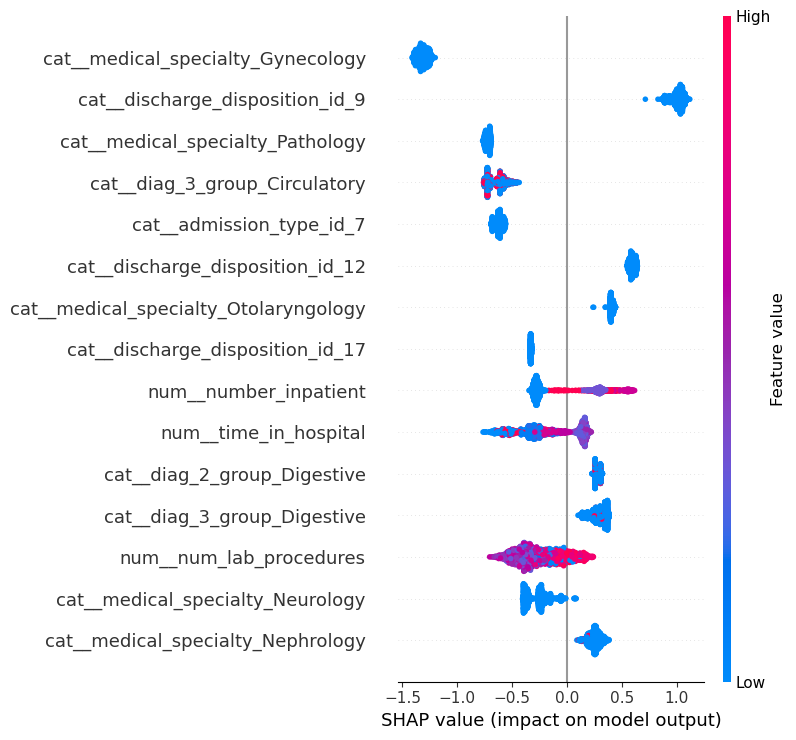

In [ ]:
#visualize 
shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=feature_names,
    max_display=15
)

#### shap means this feature influenced models prediction but it doesnt tell that a specific feature caused one class.

In [ ]:
#Subgroup + Error Analysis
#Build one analysis table
analysis_df = X_test[["age", "gender", "race"]].copy().reset_index(drop=True)

analysis_df["actual"] = y_test.reset_index(drop=True)
analysis_df["predicted"] = test_pred
analysis_df["predicted_risk"] = test_prob

print(analysis_df.head())

       age  gender             race  actual  predicted  predicted_risk
0  [40-50)  Female  AfricanAmerican       0          1        0.119650
1  [20-30)    Male        Caucasian       0          0        0.091873
2  [70-80)  Female        Caucasian       0          0        0.054527
3  [60-70)  Female        Caucasian       0          0        0.053925
4  [40-50)    Male        Caucasian       0          0        0.053389


In [ ]:
#Subgroup performance
#check:number of patients,actual readmission rate,mean predicted risk,sensitivity,specificity for gender, race, and age.
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def subgroup_metrics(data, column):

    results = []

    for group, temp in data.groupby(column):#Temp:The subset of rows corresponding only to that group.And group contains labels 

        tn, fp, fn, tp = confusion_matrix(
            temp["actual"],
            temp["predicted"],
            labels=[0, 1]
        ).ravel()

        sensitivity = (
            tp / (tp + fn)
            if (tp + fn) > 0 else np.nan
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0 else np.nan
        )

        results.append({
            column: group,
            "N": len(temp),
            "Actual_Rate": temp["actual"].mean(),
            "Mean_Predicted_Risk": temp["predicted_risk"].mean(),
            "Sensitivity": sensitivity,
            "Specificity": specificity
        })

    return pd.DataFrame(results)


gender_results = subgroup_metrics(analysis_df, "gender")
race_results = subgroup_metrics(analysis_df, "race")
age_results = subgroup_metrics(analysis_df, "age")

print("\nGENDER")
print(gender_results.round(3))

print("\nRACE")
print(race_results.round(3))

print("\nAGE")
print(age_results.round(3))


GENDER
   gender      N  Actual_Rate  Mean_Predicted_Risk  Sensitivity  Specificity
0  Female  10645        0.112                0.117        0.734        0.517
1    Male   9157        0.112                0.111        0.662        0.560

RACE
              race      N  Actual_Rate  Mean_Predicted_Risk  Sensitivity  \
0  AfricanAmerican   3707        0.107                0.115        0.697   
1            Asian    122        0.082                0.096        0.700   
2        Caucasian  14886        0.115                0.116        0.705   
3         Hispanic    371        0.105                0.102        0.795   
4            Other    298        0.087                0.096        0.654   
5          Unknown    418        0.091                0.086        0.474   

   Specificity  
0        0.537  
1        0.679  
2        0.525  
3        0.630  
4        0.680  
5        0.700  

AGE
        age     N  Actual_Rate  Mean_Predicted_Risk  Sensitivity  Specificity
0    [0-10)    29   

----

subgroup analysis tells us:  
-Gender: females had higher sensitivity (0.734) than males (0.662), while males had slightly better specificity. So the model detects more true readmissions among females but also generates more false alerts for them. That's a performance disparity worth monitoring, but by itself it doesn't prove unfairness.  
-Race: performance is reasonably similar for the two largest groups:African American sensitivity: 0.697,Caucasian sensitivity: 0.705.The Unknown race group has much lower sensitivity (0.474), but its sample is only 418, so we should treat that result cautiously. Hispanic and Asian groups are also relatively small, meaning their metrics are less stable.  
-Age: this is the most interesting subgroup result. Sensitivity generally becomes higher in older groups, but specificity falls substantially.So the model is much more likely to flag older patients as high risk. That helps catch readmissions, but it also creates many false alarms among older adults.  

----


In [47]:
#Error analysis
#classify every prediction
conditions = [
    (analysis_df["actual"] == 1) & (analysis_df["predicted"] == 1),
    (analysis_df["actual"] == 1) & (analysis_df["predicted"] == 0),
    (analysis_df["actual"] == 0) & (analysis_df["predicted"] == 1),
    (analysis_df["actual"] == 0) & (analysis_df["predicted"] == 0)
]

labels = [
    "True Positive",
    "False Negative",
    "False Positive",
    "True Negative"
]

analysis_df["error_type"] = np.select(
    conditions,
    labels,
    default="Unknown"
)

print(analysis_df["error_type"].value_counts())

error_type
True Negative     9436
False Positive    8150
True Positive     1553
False Negative     663
Name: count, dtype: int64


In [48]:
#inspect the model's confidence in its mistakes
print("\nAverage predicted risk by prediction outcome:")

print(
    analysis_df.groupby("error_type")["predicted_risk"]
    .agg(["count", "mean", "median"])
    .round(3)
)


Average predicted risk by prediction outcome:
                count   mean  median
error_type                          
False Negative    663  0.072   0.073
False Positive   8150  0.158   0.141
True Negative    9436  0.067   0.067
True Positive    1553  0.190   0.167


In [49]:
#Compare clinical characteristics of errors
error_features = X_test[
    [
        "number_inpatient",
        "number_emergency",
        "number_outpatient",
        "time_in_hospital",
        "num_medications",
        "num_lab_procedures"
    ]
].reset_index(drop=True)

error_features["error_type"] = analysis_df["error_type"]

print(
    error_features.groupby("error_type")
    .median()
    .round(2)
)

                number_inpatient  number_emergency  number_outpatient  \
error_type                                                              
False Negative               0.0               0.0                0.0   
False Positive               1.0               0.0                0.0   
True Negative                0.0               0.0                0.0   
True Positive                1.0               0.0                0.0   

                time_in_hospital  num_medications  num_lab_procedures  
error_type                                                             
False Negative               3.0             13.0                44.0  
False Positive               4.0             16.0                47.0  
True Negative                3.0             13.0                41.0  
True Positive                4.0             17.0                46.0  


----

Error analysis suggests:  
false negatives look very similar to true negatives-  
It suggests that many patients the model misses don't look obviously high-risk based on the available structured features.  
True positives and false positives are also very similar-  
So the model has identified a general pattern of:  
previous utilization + somewhat greater hospital-care intensity → higher predicted risk  
but those characteristics don't perfectly separate people who will and won't actually return.  
That helps explain why our ROC-AUC is only around 0.67.  

----

----

Clinical usefulness & responsible ML:  
Is this model clinically useful?  
Potentially as a screening/risk-stratification tool — not as an autonomous decision maker.  
Our final calibrated XGBoost model:  ROC-AUC: 0.6705,,PR-AUC: 0.2293 ,Sensitivity: 0.7008,Specificity: 0.5366,calibrated mean risk: 11.43%,actual readmission rate: 11.19%  
At threshold 0.10, it identifies about 70% of actual 30-day readmissions, which could help a hospital prioritize patients for interventions such as:  
Follow-up calls,Medication reconciliation,Earlier outpatient appointments,Discharge education,Care-management review  

But the 8,150 false positives are a major issue. If every flagged patient triggered an expensive intervention, this system could create substantial workload and alert fatigue.  
Therefore, the model makes more sense for a low-cost first-stage screening system than for automatically allocating scarce clinical resources.  

Responsible ML findings:    
We have several things we'd explicitly report:  
Fairness/subgroups: performance isn't identical across gender, race, and age. Older patients in particular receive many more positive predictions. These differences should be monitored and externally validated before deployment.  
Explainability: SHAP provides reasons behind predictions, but SHAP associations are not causal explanations.  
Calibration: we calibrated the model because raw class-weighted XGBoost probabilities were badly inflated:  Before: mean risk 45.15%,After:  11.43%,Actual: 11.19%

So an uncalibrated version should not be presented to clinicians as a probability of readmission.  
Human oversight: clinicians should use the score as decision support, not as an automatic clinical decision.  


----

#### Our final model is the calibrated XGBoost classifier with a clinically selected threshold of 0.10.It provides moderate predictive discrimination while identifying roughly 70% of patients who are readmitted within 30 days. Calibration substantially improved the reliability of predicted probabilities. Patient-level splitting and grouped cross-validation prevented repeated-patient leakage, while subgroup and error analyses revealed meaningful performance differences and a significant false-positive burden.
#### Therefore:The model could support hospital readmission risk screening, but its moderate discrimination, high false-positive rate, subgroup variation, and outdated source data mean it should not be deployed without external validation, prospective testing, clinician oversight, and ongoing monitoring.